# Facade Visibility Notebook (GeoPandas)

This notebook:
1. Loads a GeoPackage of facade line geometries.
2. Subsets to a specific **EGID**.
3. Plots all (Multi)LineString facades for that EGID on top of a street map.
4. For each line, computes a **visibility area**:
   - Buffer the line by 50 m (baseline visibility).
   - *Extend* the line 25 m beyond **each** endpoint along the line direction; buffer **only those two new points** (circles) with 50 m.
   - Subtract those endpoint-circle buffers from the baseline buffer to approximate a limited viewing cone (avoid ~grazing 90° views along the wall).
5. Plots the resulting visibility polygons on a street map.

> **Notes**
> - The basemap uses `contextily` web tiles. Run this on a machine with internet.
> - Make sure you open the dataset in a **projected CRS in meters** (we reproject to EPSG:2056 for computation and EPSG:3857 for plotting).

In [ ]:
# --- Imports
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
from shapely.geometry import LineString, MultiLineString, Point
from shapely.ops import unary_union
import shapely
import matplotlib.pyplot as plt

# For basemap tiles
import contextily as ctx

# --- User parameters
GPKG_PATH = '/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/solarenergie-eignung/fassaden_zürich.gpkg'  

# Buffer parameters (in meters, assumes projected CRS in meters)
VISIBILITY_BUFFER_M = 50.0
LINE_EXTENSION_M = 25.0
ENDPOINT_CIRCLE_R = 50.0  # often same as visibility buffer to carve grazes

# Plot settings
FIGSIZE = (10, 10)

In [11]:
# --- Load data
db = gpd.read_file(GPKG_PATH)

print("CRS:", db.crs)
print("Columns:", list(db.columns))

print(db.columns)
print(db.GWR_EGID.head())



CRS: EPSG:2056
Columns: ['objectid', 'FF_UID', 'FF_NUMMER', 'DATUM_ERSTELLUNG', 'DATUM_AENDERUNG', 'SB_UUID', 'SB_OBJEKTART', 'SB_DATUM_ERSTELLUNG', 'SB_DATUM_AENDERUNG', 'KLASSE', 'FLAECHE', 'AUSRICHTUNG', 'MSTRAHLUNG', 'GSTRAHLUNG', 'STROMERTRAG', 'STROMERTRAG_SOMMERHALBJAHR', 'STROMERTRAG_WINTERHALBJAHR', 'WAERMEERTRAG', 'DUSCHGAENGE', 'DG_HEIZUNG', 'DG_WAERMEBEDARF', 'BEDARF_WARMWASSER', 'BEDARF_HEIZUNG', 'FLAECHE_KOLLEKTOREN', 'VOLUMEN_SPEICHER', 'GWR_EGID', 'id', 'objid', 'entstehung', 'bezeichnung', 'name', 'objectid_2', 'geometry']
Index(['objectid', 'FF_UID', 'FF_NUMMER', 'DATUM_ERSTELLUNG',
       'DATUM_AENDERUNG', 'SB_UUID', 'SB_OBJEKTART', 'SB_DATUM_ERSTELLUNG',
       'SB_DATUM_AENDERUNG', 'KLASSE', 'FLAECHE', 'AUSRICHTUNG', 'MSTRAHLUNG',
       'GSTRAHLUNG', 'STROMERTRAG', 'STROMERTRAG_SOMMERHALBJAHR',
       'STROMERTRAG_WINTERHALBJAHR', 'WAERMEERTRAG', 'DUSCHGAENGE',
       'DG_HEIZUNG', 'DG_WAERMEBEDARF', 'BEDARF_WARMWASSER', 'BEDARF_HEIZUNG',
       'FLAECHE_KOLLEKTO

In [56]:
# Subset by EGID
EGID_VALUES = [302017889, 302017781]

EGID_VALUES = [149588, 149589, 149592, 149593, 149594, 149595, 149596, 149597, 149598, 149599, 149601, 149602, 149603, 149604, 149605, 149606, 149607, 149608, 149612,
               149613, 149614, 149615, 149747, 149748, 149749, 149750, 149751, 149789, 149790, 149791, 149792, 149793, 149794, 149795, 149883, 149884, 149885, 149886, 149887, 149888, 149889, 149890,
               149891, 149892, 149892, 149893, 14989, 149909, 149910, 2366463, 2366567, 2377931, 9011644, 302004417]

EGID_VALUES = [147224, 147233, 147235, 147237, 147238, 147239]

subset = db[db["GWR_EGID"].isin(EGID_VALUES)].copy()
if subset.empty:
    raise ValueError(f"No rows found for GWR_EGID in {EGID_VALUES}.")

subset = subset.set_geometry(subset.geometry)  # ensure geometry column set
subset = subset[~subset.geometry.is_empty & subset.geometry.notnull()]

print(f"Subset rows: {len(subset)}")

Subset rows: 29


In [ ]:
#subset = gpd.read_file("/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/solarenergie-eignung/plot_subset.gpkg")

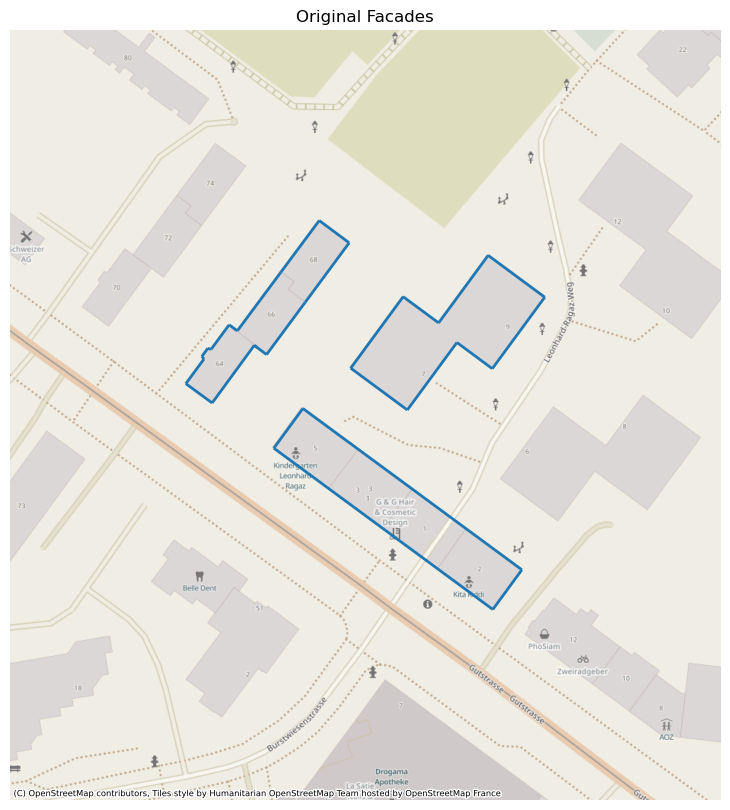

In [68]:
# --- Plot original facades (lines) on a basemap
PLOT_CRS = 'EPSG:3857'
facades_plot = subset.copy()
facades_plot = facades_plot.to_crs(PLOT_CRS)

ax = facades_plot.plot(figsize=FIGSIZE, linewidth=2)

# Get current bounds
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# Expand by 20%
dx = (xmax - xmin) * 0.4
dy = (ymax - ymin) * 0.4
ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

# Add basemap
try:
    ctx.add_basemap(ax, crs=facades_plot.crs, attribution_size=6)
except Exception as e:
    print("Basemap could not be loaded (no internet or tile server issue). Plotting without basemap.", e)

ax.set_axis_off()
ax.set_title(f"Original Facades")
plt.show()

In [58]:
# --- Helper: facade quad polygon from base line + single 45° 30 m rays ----------
import math
from shapely.geometry import LineString, MultiLineString, Point, Polygon

def _unit_vector(p_from, p_to):
    dx = p_to.x - p_from.x
    dy = p_to.y - p_from.y
    L = (dx*dx + dy*dy) ** 0.5
    if L == 0:
        return (0.0, 0.0)
    return (dx/L, dy/L)

def _angle_of_vec_deg(ux, uy):
    return math.degrees(math.atan2(uy, ux))

def _vec_from_angle_deg(angle_deg, length):
    t = math.radians(angle_deg)
    return (length * math.cos(t), length * math.sin(t))

def _endpoint_single_ray(endpoint_pt: Point, normal_angle_deg: float,
                         half_angle_deg: float, distance_m: float,
                         ray_sign: int = +1) -> Point:
    """
    One ray per endpoint at angle = normal +/- half_angle.
    ray_sign=+1 -> normal + half_angle (counterclockwise)
    ray_sign=-1 -> normal - half_angle (clockwise)
    """
    a = normal_angle_deg + ray_sign * half_angle_deg
    vx, vy = _vec_from_angle_deg(a, distance_m)
    return Point(endpoint_pt.x + vx, endpoint_pt.y + vy)

def facade_visibility_quad_polygon(
    line: LineString,
    distance_m: float = 30.0,
    half_angle_deg: float = 45.0,
    side: str = "left",
    ray_sign: int = +1  # use +1 or -1 to pick which 45° branch relative to normal
) -> Polygon | None:
    """
    Build a 4-vertex polygon per facade line:
      base = the original line endpoints (start -> end),
      apex = two points made by a single 30 m ray at ±45° from the outward normal at each endpoint.

    side: "left" or "right" relative to line direction (start->end). Chooses outward normal.
    ray_sign: choose +1 or -1 for which side of the normal to use (kept consistent for both endpoints).
    """
    if not isinstance(line, LineString) or line.length == 0:
        return None

    p_start = Point(line.coords[0])
    p_end   = Point(line.coords[-1])

    # Tangent and outward normal
    ux, uy  = _unit_vector(p_start, p_end)
    theta   = _angle_of_vec_deg(ux, uy)                 # tangent angle
    normal  = theta + 90.0 if side.lower() == "left" else theta - 90.0

    # One ray at each endpoint
    p_start_ray = _endpoint_single_ray(p_start, normal, half_angle_deg, distance_m, ray_sign=ray_sign)
    p_end_ray   = _endpoint_single_ray(p_end,   normal, half_angle_deg, distance_m, ray_sign=-ray_sign)

    # Quad order: base (start -> end) then far edge (end_ray -> start_ray)
    ring = [p_start, p_end, p_end_ray, p_start_ray, p_start]
    poly = Polygon([(pt.x, pt.y) for pt in ring])
    if not poly.is_valid:
        # try reversed far edge order if self-intersection happens on degenerate tiny lines
        ring = [p_start, p_end, p_start_ray, p_end_ray, p_start]
        poly = Polygon([(pt.x, pt.y) for pt in ring])
    return poly

def explode_to_lines(geom):
    if geom is None or geom.is_empty:
        return
    if isinstance(geom, LineString):
        yield geom
    elif isinstance(geom, MultiLineString):
        for part in geom.geoms:
            if isinstance(part, LineString):
                yield part


In [59]:
records = []
for idx, row in subset.iterrows():  # subset_m must be in a metric CRS (e.g., EPSG:2056)
    for line in explode_to_lines(row.geometry):
        poly = facade_visibility_quad_polygon(
            line,
            distance_m=30.0,      # 30 meters
            half_angle_deg=45.0,  # 45 degrees
            side="left",          # or "right" depending on which side is outward
            ray_sign=+1           # flip to -1 if you prefer the other 45° branch
        )
        if poly and not poly.is_empty:
            records.append({"GWR_EGID": row["GWR_EGID"], "source_index": idx, "geometry": poly})

vis_gdf = gpd.GeoDataFrame(records, geometry="geometry", crs=subset.crs)


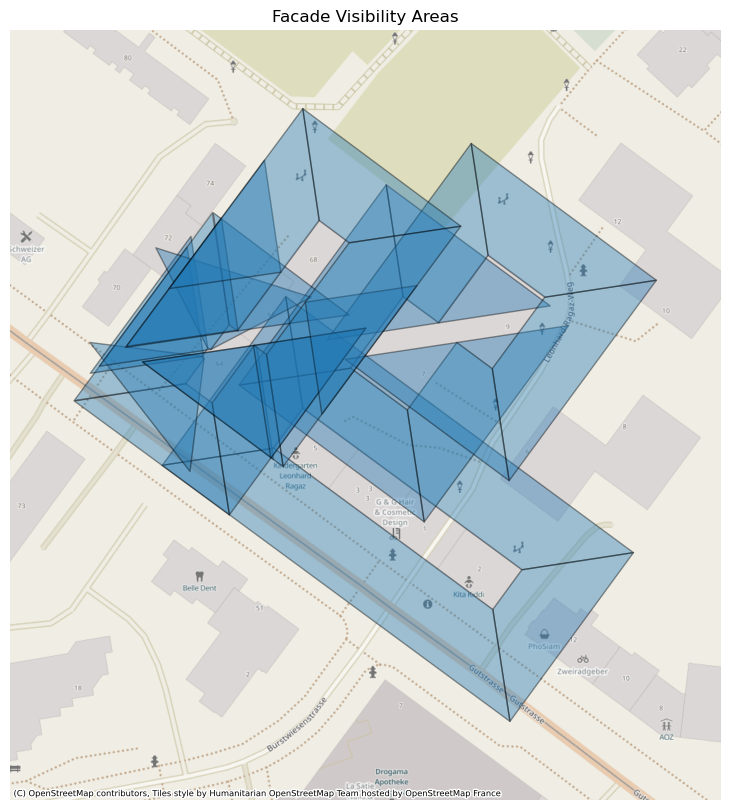

In [69]:
# --- Plot visibility polygons on a basemap
vis_plot = vis_gdf.to_crs(PLOT_CRS)

ax = vis_plot.plot(figsize=FIGSIZE, alpha=0.4, edgecolor='k')

# draw original lines on top for context
#facades_plot.boundary.plot(ax=ax, linewidth=1.0, color='black')

# Expand by 20%
dx = (xmax - xmin) * 0.4
dy = (ymax - ymin) * 0.4
ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)


# Add basemap
try:
    ctx.add_basemap(ax, crs=vis_plot.crs, attribution_size=6)
except Exception as e:
    print("Basemap could not be loaded (no internet or tile server issue). Plotting without basemap.", e)

ax.set_axis_off()
ax.set_title(f"Facade Visibility Areas")
plt.show()